In [1]:
%pip install requests
%pip install matplotlib
%pip install pandas
%pip install numpy
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Question 1: During the last 15 years fo the Bundesliga, inspecting 15 minute intervalls, when are the most goals scored during a match? How does this differ between teams? 
What info do we need to answer this question?  
for every team: for every season: goals scored & time of scoring  
(in that match: hometurf or not)  
having gathered that: construct averages for every team (seperate as well as total) over the 90 minutes


In [24]:
'''
1. Gather scores of teams and total scores in intervalls for last 15 seasons (season 09/10 to 24/25)
'''
total_matches = 0
total_goals = {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}
teams = {}

for i in range(0,15):
    year = 2010 + i
    url = 'https://api.openligadb.de/getmatchdata/bl1/' + str(year) 
    response = json.loads(requests.get(url).text)
    for match in response:

        # ID and current score Bookkeeping
        t1_id = match['team1']['teamId'] 
        t2_id = match['team2']['teamId']
        t1_score = 0
        t2_score = 0

        # Add new entries to teams dict
        if t1_id not in teams.keys(): # Team hasn't been in BL1 ever before
            teams[t1_id] = {'name' : match['team1']['teamName'], 'matches' : 0, 'total' : {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}}
        if year not in teams[t1_id].keys(): # Team hasn't been in a match this year before
            teams[t1_id][year] = {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}

        if t2_id not in teams.keys(): 
            teams[t2_id] = {'name' : match['team2']['teamName'], 'matches' : 0, 'total' : {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}}
        if year not in teams[t2_id].keys(): 
            teams[t2_id][year] = {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0} 

        #No. of matches Bookkeeping
        teams[t1_id]['matches'] += 1 
        teams[t2_id]['matches'] += 1 
        total_matches += 1
        
        # Sum goals for intervals
        for goal in match['goals']:
            if type(goal['matchMinute']) == int: # Check if data isnt empty (divergence point for "ignore goal vs ignore match")
                interval = ((goal['matchMinute'] // 15) + 1) * 15
                if goal['scoreTeam1'] > t1_score: # Check which team scored the goal
                    t1_score = goal['scoreTeam1'] 
                    teams[t1_id][year][interval] += 1   # Update current year
                    teams[t1_id]['total'][interval] += 1 # Update total sum of goals in that interval
                else:
                    t2_score = goal['scoreTeam2']
                    teams[t2_id][year][interval] += 1
                    teams[t2_id]['total'][interval] += 1
                total_goals[interval] += 1 # Update total goals of all seasons in that intervall

'''
2. Calculate statistics for every team over all years

avg = average. Looks at percentage of goals scored in an interval compared to total goals scored
i.e. "When team x scores a goal, how likely is it that it happened in the first/second/last 15 minutes?"

gpi = goals per interval. Looks at the amount of goals scored in an interval over all matches
i.e. "How many goals does a team score in the first/second/last 15 minutes in any given match?"
'''


# Whole Bundesliga statistics
total_gpi = {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}
total_avg = {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}
number_of_goals = sum(total_goals.values())

for interval in total_goals.keys(): 
    total_gpi[interval] = total_goals[interval] / total_matches
    total_avg[interval] = total_goals[interval] / number_of_goals
    

print('Bundesliga:', '\n avg:', total_avg, '\n gpi:', total_gpi)

# Specific team statistics
for team in teams: 
    teams[team]['gpi'] = {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}
    teams[team]['avg'] = {15:0, 30:0, 45:0, 60:0, 75:0, 90:0, 105:0}
    tg = sum(teams[team]['total'].values())

    for interval in teams[team]['total'].keys():
        teams[team]['gpi'][interval] = teams[team]['total'][interval] / teams[team]['matches']  
        teams[team]['avg'][interval] = teams[team]['total'][interval] / tg


    print(teams[team]['name'], '\n avg:', teams[team]['avg'], '\n gpi:', teams[team]['gpi'])


Bundesliga: 
 avg: {15: 0.1180033569291396, 30: 0.148288695906006, 45: 0.15149967160475808, 60: 0.1811282200977888, 75: 0.1682843173027804, 90: 0.17492519886156316, 105: 0.05787053929796395} 
 gpi: {15: 0.35228758169934643, 30: 0.44270152505446625, 45: 0.4522875816993464, 60: 0.5407407407407407, 75: 0.50239651416122, 90: 0.5222222222222223, 105: 0.17276688453159042}
FC Bayern München 
 avg: {15: 0.11734317343173432, 30: 0.15424354243542435, 45: 0.16605166051660517, 60: 0.17343173431734318, 75: 0.16826568265682657, 90: 0.16457564575645756, 105: 0.05608856088560885} 
 gpi: {15: 0.31176470588235294, 30: 0.40980392156862744, 45: 0.4411764705882353, 60: 0.46078431372549017, 75: 0.4470588235294118, 90: 0.4372549019607843, 105: 0.14901960784313725}
VfL Wolfsburg 
 avg: {15: 0.14760638297872342, 30: 0.15425531914893617, 45: 0.1449468085106383, 60: 0.1675531914893617, 75: 0.1595744680851064, 90: 0.18085106382978725, 105: 0.04521276595744681} 
 gpi: {15: 0.21764705882352942, 30: 0.22745098039215

Text(0, 0.5, 'percentage of goals scored')

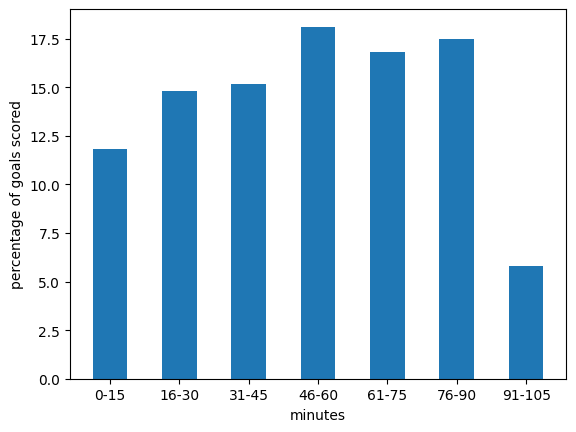

In [25]:
'''
3. Visualize the results
'''

rounded = [x*100 for x in total_avg.values()]

# Percentages of total goals scored in 1st bundesliga
plot = plt.bar(['0-15','16-30','31-45','46-60','61-75','76-90','91-105'], rounded, 0.5)
plt.xlabel('minutes')
plt.ylabel('percentage of goals scored')

# Maybe some specific teams here?
